# Optuna Study Visualization: Budget DPO HPO

This notebook visualizes the Optuna study from `checkpoints/optuna/budget_dpo_hpo_0503_200745.db` to extract insights for improving future hyperparameter optimization runs.

In [5]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
    plot_contour,
    plot_slice,
    plot_intermediate_values,
    plot_edf,
)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the study
db_path = '/storage/arik/nlp_final_project/checkpoints/optuna/budget_dpo_hpo_0503_200745.db'

# Verify file exists
if not os.path.exists(db_path):
    raise FileNotFoundError(f"Database not found: {db_path}")

# Load with explicit study name
study = optuna.load_study(study_name='budget_dpo_hpo_0503_200745', storage=f'sqlite:///{db_path}')

print(f"Study name: {study.study_name}")
print(f"Number of trials: {len(study.trials)}")
print(f"Best value (neg val loss): {study.best_value:.6f}")
print(f"\nBest parameters:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")

Study name: budget_dpo_hpo_0503_200745
Number of trials: 20
Best value (neg val loss): -1.986553

Best parameters:
  lr: 7.926323303002474e-07
  dpo_beta: 0.1919304446108942
  lambda_easy: 0.2808744913808333
  lambda_hard: 0.00010665211715965037
  kl_penalty_weight: 0.00013996648792338374
  batch_size: 8
  gradient_accumulation_steps: 1
  loss_type: dpo
  length_ratio_easy: 1.9624608285172611
  length_ratio_hard: 2.988406270032654
  max_pairs_per_problem: 13


## 1. Trial Summary Statistics

In [6]:
from optuna.trial import TrialState

# Count trial states
states = [t.state for t in study.trials]
state_counts = {state: states.count(state) for state in set(states)}

print("Trial States:")
for state, count in state_counts.items():
    print(f"  {state.name}: {count}")

# Get completed trials
completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
pruned_trials = [t for t in study.trials if t.state == TrialState.PRUNED]

print(f"\nCompleted trials: {len(completed_trials)}")
print(f"Pruned trials: {len(pruned_trials)}")

# Summary statistics for completed trials
if completed_trials:
    values = [t.value for t in completed_trials if t.value is not None]
    print(f"\nCompleted trial values (neg val loss):")
    print(f"  Best: {max(values):.6f}")
    print(f"  Worst: {min(values):.6f}")
    print(f"  Mean: {np.mean(values):.6f}")
    print(f"  Std: {np.std(values):.6f}")

Trial States:
  COMPLETE: 11
  PRUNED: 9

Completed trials: 11
Pruned trials: 9

Completed trial values (neg val loss):
  Best: inf
  Worst: -1.986553
  Mean: inf
  Std: nan


/usr/local/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


## 2. Optimization History

Shows how the optimization progressed over trials. The best value found so far is shown in orange.

In [7]:
fig = plot_optimization_history(study)
fig.update_layout(title="Optimization History - Budget DPO HPO", height=500)
fig.show()

## 3. Parameter Importances

Shows which hyperparameters have the most impact on the objective value. Use this to focus future searches on the most influential parameters.

In [8]:
# Compute parameter importances using fANOVA
try:
    importances = optuna.importance.get_param_importances(study, evaluator=optuna.importance.FanovaImportanceEvaluator())
    print("Parameter Importances (fANOVA):")
    for param, importance in importances.items():
        print(f"  {param}: {importance:.4f}")

    fig = plot_param_importances(study, evaluator=optuna.importance.FanovaImportanceEvaluator())
    fig.update_layout(title="Hyperparameter Importances (fANOVA)", height=600)
    fig.show()
except Exception as e:
    print(f"Could not compute fANOVA importances: {e}")
    print("Trying default importance...")
    fig = plot_param_importances(study)
    fig.update_layout(title="Hyperparameter Importances", height=600)
    fig.show()

[W 2026-05-04 16:01:31,826] Trial 9 is omitted in visualization because its objective value is inf or nan.


Parameter Importances (fANOVA):
  max_pairs_per_problem: 0.2765
  lambda_easy: 0.2763
  lr: 0.1189
  dpo_beta: 0.0895
  length_ratio_easy: 0.0893
  lambda_hard: 0.0694
  gradient_accumulation_steps: 0.0288
  length_ratio_hard: 0.0272
  loss_type: 0.0144
  kl_penalty_weight: 0.0097
  batch_size: 0.0000


## 4. Parallel Coordinate Plot

Shows relationships between all parameters and the objective value. Look for parameter regions where the objective is best (darker blue lines).

In [9]:
fig = plot_parallel_coordinate(study)
fig.update_layout(title="Parallel Coordinate Plot - All Parameters", height=600)
fig.show()

[W 2026-05-04 16:01:32,050] Trial 9 is omitted in visualization because its objective value is inf or nan.


## 5. Slice Plots (Parameter vs Objective)

Shows how each parameter individually affects the objective. Look for parameter ranges that consistently give better results.

In [10]:
fig = plot_slice(study)
fig.update_layout(title="Parameter Slice Plots", height=800)
fig.show()

[W 2026-05-04 16:01:32,073] Trial 9 is omitted in visualization because its objective value is inf or nan.


## 6. Contour Plots - Most Important Parameters

Shows interactions between the most important parameter pairs. Darker regions are better.

In [11]:
# Get top parameters by importance
try:
    importances = optuna.importance.get_param_importances(study)
    top_params = list(importances.keys())[:5]  # Top 5 most important

    print(f"Top 5 most important parameters: {top_params}")

    # Create contour plots for top parameter pairs
    for i in range(len(top_params)):
        for j in range(i+1, len(top_params)):
            param_x = top_params[i]
            param_y = top_params[j]
            try:
                fig = plot_contour(study, params=[param_x, param_y])
                fig.update_layout(title=f"Contour: {param_x} vs {param_y}", height=500)
                fig.show()
            except Exception as e:
                print(f"Could not plot contour for {param_x} vs {param_y}: {e}")
except Exception as e:
    print(f"Could not generate contour plots: {e}")

[W 2026-05-04 16:01:32,330] Trial 9 is omitted in visualization because its objective value is inf or nan.


Top 5 most important parameters: ['max_pairs_per_problem', 'lambda_easy', 'lambda_hard', 'dpo_beta', 'lr']


[W 2026-05-04 16:01:32,357] Trial 9 is omitted in visualization because its objective value is inf or nan.


[W 2026-05-04 16:01:32,369] Trial 9 is omitted in visualization because its objective value is inf or nan.


[W 2026-05-04 16:01:32,382] Trial 9 is omitted in visualization because its objective value is inf or nan.


...

[W 2026-05-04 16:01:32,409] Trial 9 is omitted in visualization because its objective value is inf or nan.


[W 2026-05-04 16:01:32,422] Trial 9 is omitted in visualization because its objective value is inf or nan.


[W 2026-05-04 16:01:32,436] Trial 9 is omitted in visualization because its objective value is inf or nan.


[W 2026-05-04 16:01:32,450] Trial 9 is omitted in visualization because its objective value is inf or nan.


[W 2026-05-04 16:01:32,464] Trial 9 is omitted in visualization because its objective value is inf or nan.


## 7. Intermediate Values (for Pruned Trials)

Shows how trials progressed before being pruned. Helps understand if the pruning is working effectively.

In [12]:
fig = plot_intermediate_values(study)
fig.update_layout(title="Intermediate Values (Pruning Analysis)", height=500)
fig.show()

[W 2026-05-04 16:01:32,493] You need to set up the pruning feature to utilize `plot_intermediate_values()`


## 8. Empirical Distribution Function (EDF)

Shows the cumulative distribution of objective values. Steeper curve at higher values indicates more efficient optimization.

In [13]:
fig = plot_edf(study)
fig.update_layout(title="Empirical Distribution Function", height=500)
fig.show()

[W 2026-05-04 16:01:32,508] Trial 9 is omitted in visualization because its objective value is inf or nan.


## 9. Detailed Trial Data Analysis

In [14]:
# Create DataFrame with all trial data
trials_data = []
for trial in study.trials:
    if trial.state == TrialState.COMPLETE and trial.value is not None:
        data = {'trial_number': trial.number, 'value': trial.value, 'state': trial.state.name}
        data.update(trial.params)
        trials_data.append(data)

df = pd.DataFrame(trials_data)
print(f"DataFrame shape: {df.shape}")
print(f"\nTop 5 trials by objective value (higher is better, since neg val loss):")
df_sorted = df.sort_values('value', ascending=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(df_sorted.head(10).to_string(index=False))

DataFrame shape: (11, 14)

Top 5 trials by objective value (higher is better, since neg val loss):
 trial_number     value    state           lr  dpo_beta  lambda_easy  lambda_hard  kl_penalty_weight  batch_size  gradient_accumulation_steps loss_type  length_ratio_easy  length_ratio_hard  max_pairs_per_problem
            9       inf COMPLETE 1.316639e-06  0.165105     0.055140     0.001233           0.771131           8                            1     simpo           3.010716           1.102958                      9
            0 -0.297316 COMPLETE 1.535529e-06  0.446359     0.065049     0.006251           0.000421           8                            1     simpo           4.329771           1.424678                      7
            1 -0.434816 COMPLETE 8.661334e-07  0.100742     0.019947     0.001976           0.001462           8                            4       dpo           3.056938           2.184829                      4
           12 -0.710563 COMPLETE 1.083367e-06  0.

In [15]:
# Parameter correlation with objective
print("\nCorrelation between parameters and objective (neg val loss):")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'value' in numeric_cols:
    correlations = df[numeric_cols].corr()['value'].sort_values(ascending=False)
    print(correlations[1:].to_string())  # Exclude self-correlation


Correlation between parameters and objective (neg val loss):
length_ratio_easy              0.332333
lambda_hard                    0.264854
dpo_beta                       0.248921
kl_penalty_weight              0.205491
gradient_accumulation_steps    0.183322
lr                            -0.027513
trial_number                  -0.501712
lambda_easy                   -0.501984
length_ratio_hard             -0.579539
max_pairs_per_problem         -0.742629
batch_size                          NaN


## 10. Parameter Distributions for Top vs All Trials

Compare parameter distributions between top-performing trials and all trials.

/tmp/ipykernel_169754/1087852417.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_169754/1087852417.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



Top 25% threshold (neg val loss): -0.572690
Top trials: 3, Other trials: 8


/tmp/ipykernel_169754/1087852417.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_169754/1087852417.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_169754/1087852417.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_169754/1087852417.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_169754/1087852417.py:29: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3

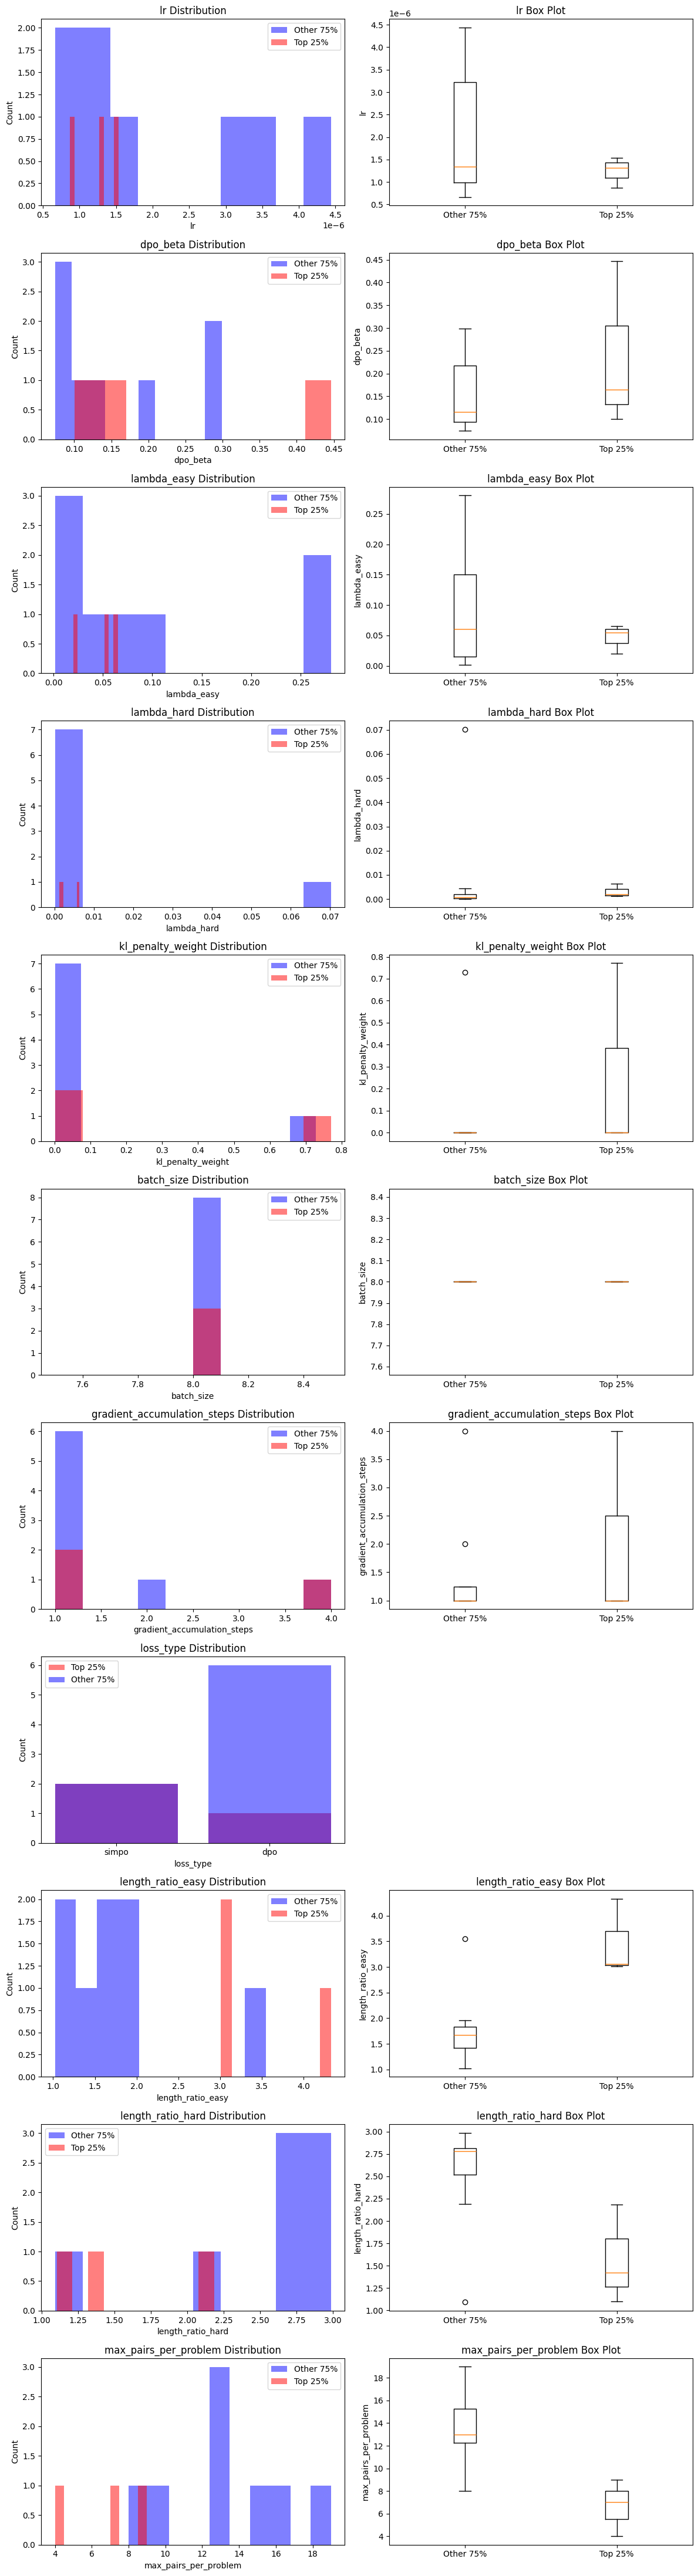

In [16]:
# Compare top 25% trials vs rest
if len(df) >= 4:
    threshold = df['value'].quantile(0.75)
    top_trials = df[df['value'] >= threshold]
    other_trials = df[df['value'] < threshold]

    print(f"Top 25% threshold (neg val loss): {threshold:.6f}")
    print(f"Top trials: {len(top_trials)}, Other trials: {len(other_trials)}")

    # Plot parameter distributions
    param_cols = [col for col in df.columns if col not in ['trial_number', 'value', 'state']]
    n_params = len(param_cols)

    fig, axes = plt.subplots(n_params, 2, figsize=(12, 4*n_params))
    if n_params == 1:
        axes = axes.reshape(1, -1)

    for idx, param in enumerate(param_cols):
        # Histogram comparison
        if df[param].dtype in [np.float64, np.int64]:
            axes[idx, 0].hist(other_trials[param], alpha=0.5, label='Other 75%', bins=10, color='blue')
            axes[idx, 0].hist(top_trials[param], alpha=0.5, label='Top 25%', bins=10, color='red')
            axes[idx, 0].set_xlabel(param)
            axes[idx, 0].set_ylabel('Count')
            axes[idx, 0].legend()
            axes[idx, 0].set_title(f'{param} Distribution')

            # Box plot comparison
            axes[idx, 1].boxplot([other_trials[param].dropna(), top_trials[param].dropna()], labels=['Other 75%', 'Top 25%'])
            axes[idx, 1].set_title(f'{param} Box Plot')
            axes[idx, 1].set_ylabel(param)
        else:
            # Categorical parameter
            top_counts = top_trials[param].value_counts()
            other_counts = other_trials[param].value_counts()
            axes[idx, 0].bar(top_counts.index, top_counts.values, alpha=0.5, label='Top 25%', color='red')
            axes[idx, 0].bar(other_counts.index, other_counts.values, alpha=0.5, label='Other 75%', color='blue')
            axes[idx, 0].set_xlabel(param)
            axes[idx, 0].set_ylabel('Count')
            axes[idx, 0].legend()
            axes[idx, 0].set_title(f'{param} Distribution')
            axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough trials for top/bottom comparison")

## 11. Key Insights and Recommendations

Based on the analysis above, here are the key insights for improving future HPO runs:

In [17]:
print("="*80)
print("KEY INSIGHTS AND RECOMMENDATIONS FOR NEXT HPO RUN")
print("="*80)

# 1. Best parameters found
print("\n1. BEST PARAMETERS FOUND:")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")

# 2. Parameter importance insights
try:
    importances = optuna.importance.get_param_importances(study)
    print("\n2. PARAMETER IMPORTANCE RANKING:")
    for i, (param, imp) in enumerate(importances.items(), 1):
        print(f"   {i}. {param}: {imp:.4f}")

    print("\n   RECOMMENDATION: Focus search on the top 3-4 parameters.")
    print(f"   The top parameter ({list(importances.keys())[0]}) explains "
          f"{list(importances.values())[0]*100:.1f}% of variance.")
except:
    pass

# 3. Trial efficiency
print(f"\n3. TRIAL EFFICIENCY:")
print(f"   - Completed trials: {len(completed_trials)}/{len(study.trials)} ({len(completed_trials)/len(study.trials)*100:.1f}%)")
print(f"   - Pruned trials: {len(pruned_trials)}/{len(study.trials)} ({len(pruned_trials)/len(study.trials)*100:.1f}%)")
if len(pruned_trials) / len(study.trials) > 0.5:
    print("   RECOMMENDATION: High pruning rate is good - consider increasing n_trials.")

# 4. Parameter range analysis
print("\n4. PARAMETER RANGE ANALYSIS:")
for param in study.best_params.keys():
    values = [t.params[param] for t in completed_trials if param in t.params]
    if values and all(isinstance(v, (int, float)) for v in values):
        best_val = study.best_params[param]
        min_val, max_val = min(values), max(values)
        position = (best_val - min_val) / (max_val - min_val) if max_val > min_val else 0.5
        print(f"   {param}: best at {position*100:.0f}th percentile of search range")
        if position < 0.1 or position > 0.9:
            print(f"      WARNING: Best value near boundary - consider extending search range!")

# 5. Specific recommendations
print("\n5. SPECIFIC RECOMMENDATIONS FOR NEXT RUN:")
print("   a) Increase n_trials to 50-100 for better exploration")
print("   b) Consider narrowing search ranges for parameters with low importance")
print("   c) For parameters where best is near boundary, extend that boundary")
print("   d) Use the best parameters as starting point with tighter search around them")
print("   e) Consider using TPESampler with multivariate=True for better sampling")

print("\n" + "="*80)

KEY INSIGHTS AND RECOMMENDATIONS FOR NEXT HPO RUN

1. BEST PARAMETERS FOUND:
   lr: 7.926323303002474e-07
   dpo_beta: 0.1919304446108942
   lambda_easy: 0.2808744913808333
   lambda_hard: 0.00010665211715965037
   kl_penalty_weight: 0.00013996648792338374
   batch_size: 8
   gradient_accumulation_steps: 1
   loss_type: dpo
   length_ratio_easy: 1.9624608285172611
   length_ratio_hard: 2.988406270032654
   max_pairs_per_problem: 13

2. PARAMETER IMPORTANCE RANKING:
   1. lambda_easy: 0.2447
   2. max_pairs_per_problem: 0.2221
   3. lambda_hard: 0.1304
   4. dpo_beta: 0.1233
   5. lr: 0.0975
   6. length_ratio_easy: 0.0576
   7. length_ratio_hard: 0.0483
   8. kl_penalty_weight: 0.0357
   9. gradient_accumulation_steps: 0.0343
   10. loss_type: 0.0060
   11. batch_size: 0.0000

   RECOMMENDATION: Focus search on the top 3-4 parameters.
   The top parameter (lambda_easy) explains 24.5% of variance.

3. TRIAL EFFICIENCY:
   - Completed trials: 11/20 (55.0%)
   - Pruned trials: 9/20 (45.0%

## 12. Generate Optimized Search Space for Next Run

Based on the analysis, here's a suggested search space for the next HPO run.

In [18]:
print("Suggested search space for next run (based on current best):")
print("\n" + "-"*80)
print("def suggest_parameters(trial):")
print("    # Learning rate - best was very low")
best_lr = study.best_params.get('lr', 1e-6)
print(f"    lr = trial.suggest_float('lr', {best_lr/2:.2e}, {best_lr*4:.2e}, log=True)")

# dpo_beta
best_beta = study.best_params.get('dpo_beta', 0.2)
print(f"    dpo_beta = trial.suggest_float('dpo_beta', {max(0.05, best_beta/2):.3f}, {min(0.5, best_beta*2):.3f})")

# lambda_easy
best_lambda_easy = study.best_params.get('lambda_easy', 0.3)
print(f"    lambda_easy = trial.suggest_float('lambda_easy', {max(0.01, best_lambda_easy/3):.3f}, {min(0.5, best_lambda_easy*2):.3f})")

# lambda_hard
best_lambda_hard = study.best_params.get('lambda_hard', 0.0001)
print(f"    lambda_hard = trial.suggest_float('lambda_hard', {best_lambda_hard/10:.6f}, {max(0.1, best_best_lambda_hard*10):.4f}, log=True)")

# kl_penalty
best_kl = study.best_params.get('kl_penalty_weight', 0.0001)
print(f"    kl_penalty_weight = trial.suggest_float('kl_penalty_weight', {best_kl/10:.6f}, {max(0.1, best_kl*10):.4f}, log=True)")

# length ratios
best_len_easy = study.best_params.get('length_ratio_easy', 2.0)
best_len_hard = study.best_params.get('length_ratio_hard', 3.0)
print(f"    length_ratio_easy = trial.suggest_float('length_ratio_easy', {max(1.0, best_len_easy/1.5):.2f}, {min(4.0, best_len_easy*1.5):.2f})")
print(f"    length_ratio_hard = trial.suggest_float('length_ratio_hard', {max(1.0, best_len_hard/1.5):.2f}, {min(5.0, best_len_hard*1.5):.2f})")

# max_pairs
best_max_pairs = study.best_params.get('max_pairs_per_problem', 13)
print(f"    max_pairs_per_problem = trial.suggest_int('max_pairs_per_problem', {max(5, best_max_pairs-5)}, {min(30, best_max_pairs+10)})")

print("\n    # Consider adding:")
print("    # loss_type = trial.suggest_categorical('loss_type', ['dpo', 'ipo', 'simpo'])")
print("    # batch_size = trial.suggest_categorical('batch_size', [4, 8, 16])")
print("    # gradient_accumulation_steps = trial.suggest_categorical('gradient_accumulation_steps', [1, 2, 4, 8])")
print("-"*80)

Suggested search space for next run (based on current best):

--------------------------------------------------------------------------------
def suggest_parameters(trial):
    # Learning rate - best was very low
    lr = trial.suggest_float('lr', 3.96e-07, 3.17e-06, log=True)
    dpo_beta = trial.suggest_float('dpo_beta', 0.096, 0.384)
    lambda_easy = trial.suggest_float('lambda_easy', 0.094, 0.500)


NameError: name 'best_best_lambda_hard' is not defined